# b. Synthetic — 1nW Trans10 (true values; 12d model + Fisher)

Closed-loop diagnostic: the target FWHM distribution is **generated by our own simulator at the true (μ, γ, σ_phys, λ)**. Same pipeline as the 15-series (2D KDE likelihood + REINFORCE/implicit-diff gradients + Fisher CRB). If the optimizer reproduces the truth, the model is healthy; if not, the miss is a pure model gap.

| | |
|---|---|
| Target | synthetic, 358 pts @ true values |
| Power / Trans | 1nW / Trans10 |

In [1]:
import math, time, os, sys
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float32)

for _p in [os.getcwd(), os.path.join(os.getcwd(), '..'), os.path.join(os.getcwd(), '..', '..')]:
    if os.path.isdir(os.path.join(_p, 'src')):
        sys.path.insert(0, _p)
        REPO_ROOT = _p
        break
os.chdir(REPO_ROOT)

from src.fitting import (
    _raw_from_width as _rw,
    log_pdf, nll, fwhm_from_theta, fit_profile
)
from src.samplers import draw_fixed_noise, build_photons
from src.implicit import compute_fwhm_and_dgamma

print('Imports OK')

Imports OK


In [2]:
# --- experiment parameters (TRUE values; synthetic target) ---
POWER = '1nW'
TRANSMISSION = 'Trans10'

MU_TRUE = 12.372       # pho_normal_mean
SIGMA_PROP = 3.445   # pho_normal_std   (fixed, true)
LAMBDA_ = 2.122      # pho_noise_poisson_mean (fixed, true)
GAMMA_TRUE = 8.5   # true γ reference (median FWHM @ Trans100 / 2)
GAMMA_INIT = 0.5 * GAMMA_TRUE   # start off-truth (diagnostic)
MU_INIT = 0.5 * MU_TRUE   # 0.5 * MU_TRUE
N_TARGET = 358    # mirror the real experiment's row count

# --- optimization (as 12d / 15-series) ---
N_RUNS = 500
N_ITER = 80
LR_MU = 15.0
LR_GAMMA = 0.5
CLIP = 10.0
SEED = 42

# --- fisher block (as 12d) ---
M_FINAL = 500
FISHER_SEEDS = 5
FISHER_BASE_SEED = 7000

print('Parameters set')

Parameters set


## Generate the synthetic target from the TRUE values

- draw photon counts n ~ N(μ_true, σ_phys), background b ~ Poisson(λ_true)
- build photons with Cauchy width γ_true, fit Lorentzian → (FWHM, fit-σ)
- same (FWHM, fit-σ) pair structure as the real data files
- Scott bandwidths h_f, h_s from the synthetic target (as in the 15-series)

synthetic target: 358 pts @ true μ=12.372, γ=8.5 (2γ=17.0)
target FWHM: 23.4 ± 19.6 MHz
target err:  2.83 ± 2.95 MHz  (median 2.07)
Scott bandwidths: h_f=7.37 MHz, h_s=1.106 MHz


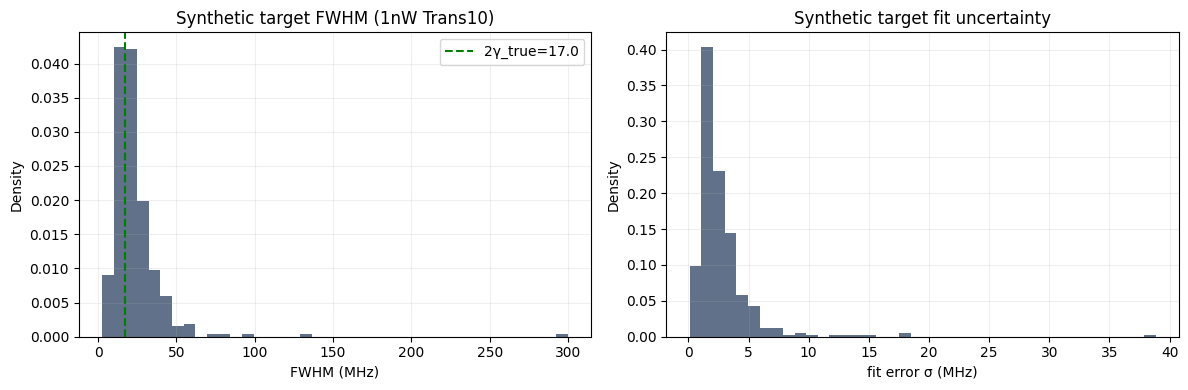

In [3]:
def _fit_fn(ph):
    return fit_profile(ph, n_iters=80, model='lorentzian', uniform_bg=False)

def _fwhm_fn(th):
    return fwhm_from_theta(th, model='lorentzian')

def _nll_fn(th, ph):
    return nll(th, ph, model='lorentzian', uniform_bg=False)

# --- synthetic target: generated by the model itself at the TRUE values ---
# Closed-loop diagnostic: same pipeline as the 15-series, but the "experiment"
# is produced by our own simulator at (mu_true, gamma_true, sigma_phys, lambda).
# If the optimizer recovers the truth, the model is healthy; any miss = model gap.
SYNTH_SEED = 12345
rng_t = np.random.default_rng(SYNTH_SEED)
fwhms_t, sigmas_t = [], []
for _ in range(N_TARGET):
    u, b, n = draw_fixed_noise(MU_TRUE, SIGMA_PROP, LAMBDA_, rng_t)
    fw, sig, dg = compute_fwhm_and_dgamma(
        GAMMA_TRUE, u.numpy(), b.numpy(),
        _fit_fn, _fwhm_fn, _nll_fn, n_params=2)
    fwhms_t.append(fw); sigmas_t.append(sig)

target_f = torch.tensor(fwhms_t, dtype=torch.float32)
target_s = torch.tensor(sigmas_t, dtype=torch.float32)

SCOTT_EXP = N_TARGET ** (-1.0 / 6.0)
H_F = float(target_f.std()) * SCOTT_EXP
H_S = float(target_s.std()) * SCOTT_EXP

print(f"synthetic target: {N_TARGET} pts @ true μ={MU_TRUE}, γ={GAMMA_TRUE} (2γ={2*GAMMA_TRUE:.1f})")
print(f"target FWHM: {target_f.mean():.1f} ± {target_f.std():.1f} MHz")
print(f"target err:  {target_s.mean():.2f} ± {target_s.std():.2f} MHz  (median {torch.median(target_s):.2f})")
print(f"Scott bandwidths: h_f={H_F:.2f} MHz, h_s={H_S:.3f} MHz")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(target_f.numpy(), bins=40, density=True, alpha=0.7, color='#1d3557')
ax1.axvline(2 * GAMMA_TRUE, color='g', ls='--', label=f'2γ_true={2*GAMMA_TRUE:.1f}')
ax1.set_xlabel('FWHM (MHz)'); ax1.set_ylabel('Density')
ax1.set_title(f'Synthetic target FWHM ({POWER} {TRANSMISSION})')
ax1.legend(); ax1.grid(alpha=0.2)
ax2.hist(target_s.numpy(), bins=40, density=True, alpha=0.7, color='#1d3557')
ax2.set_xlabel('fit error σ (MHz)'); ax2.set_ylabel('Density')
ax2.set_title('Synthetic target fit uncertainty')
ax2.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## KDE likelihood & gradients (identical to 12d / 15-series)

```
p̂(f, s; θ) = (1/M) Σᵢ exp(−(f−fᵢ)²/2h_f² − (s−sᵢ)²/2h_s²)
L(θ) = −(1/N) Σ_k log p̂(f_k, s_k; θ)
```
μ gradient: weighted REINFORCE with responsibility weights; γ gradient: implicit
differentiation through the fit (see 12d).

In [4]:
def kde_scores(sim_f, sim_s, sim_n, sim_df, sim_ds, data_f, data_s, h_f, h_s, mu):
    d_f = data_f[:, None] - sim_f[None, :]
    d_s = data_s[:, None] - sim_s[None, :]
    W = torch.exp(-0.5 * (d_f / h_f) ** 2 - 0.5 * (d_s / h_s) ** 2)
    w = W / W.sum(dim=1, keepdim=True).clamp_min(1e-12)
    score = (sim_n[None, :] - mu) / SIGMA_PROP ** 2
    s_mu = (w * score).sum(dim=1)
    dlogG = (d_f * sim_df[None, :]) / h_f ** 2 + (d_s * sim_ds[None, :]) / h_s ** 2
    s_gamma = (w * dlogG).sum(dim=1)
    logp = torch.log((W.sum(dim=1) / len(sim_f)).clamp_min(1e-30))
    nll_val = -logp.mean()
    return s_mu, s_gamma, nll_val, w


def kde_scores_1d(sim_f, sim_n, sim_df, data_f, h_f, mu):
    d_f = data_f[:, None] - sim_f[None, :]
    W = torch.exp(-0.5 * (d_f / h_f) ** 2)
    w = W / W.sum(dim=1, keepdim=True).clamp_min(1e-12)
    score = (sim_n[None, :] - mu) / SIGMA_PROP ** 2
    s_mu = (w * score).sum(dim=1)
    dlogG = (d_f * sim_df[None, :]) / h_f ** 2
    s_gamma = (w * dlogG).sum(dim=1)
    return s_mu, s_gamma, w

print('KDE likelihood functions ready')

KDE likelihood functions ready


## Joint optimization loop (as 12d / 15-series)

N_ITER=80 × N_RUNS=500, μ LR 15→4.5, γ LR 0.5, clip ±10. True σ_phys and λ fixed.

In [5]:
t_total = time.time()
mu_val = float(MU_INIT)
gamma_val = float(GAMMA_INIT)
history = []

print(f"μ_init={MU_INIT:.2f}, γ_init={GAMMA_INIT:.1f} | true μ={MU_TRUE}, true γ={GAMMA_TRUE}")
print(f"σ_phys={SIGMA_PROP:.2f} (fixed), λ={LAMBDA_:.2f} (fixed), N_target={N_TARGET}\n")

for step in range(N_ITER):
    rng2 = np.random.default_rng(SEED + step)
    fwhms, sigmas, dfs, dsigmas, ns = [], [], [], [], []

    for _ in range(N_RUNS):
        u, b, n = draw_fixed_noise(mu_val, SIGMA_PROP, LAMBDA_, rng2)
        fw, sig, dg = compute_fwhm_and_dgamma(
            gamma_val, u.numpy(), b.numpy(),
            _fit_fn, _fwhm_fn, _nll_fn, n_params=2
        )
        fwhms.append(fw); sigmas.append(sig); dfs.append(dg)
        dsigmas.append(min(2.0 / math.sqrt(max(int(n), 1)), 2.0))
        ns.append(n)

    ft = torch.tensor(fwhms, dtype=torch.float32)
    si_t = torch.tensor(sigmas, dtype=torch.float32)
    nt = torch.tensor(ns, dtype=torch.float32)
    dg_t = torch.tensor(dfs, dtype=torch.float32)
    ds_t = torch.tensor(dsigmas, dtype=torch.float32)

    s_mu, s_gamma, nll_val, w = kde_scores(
        ft, si_t, nt, dg_t, ds_t,
        target_f, target_s, H_F, H_S, mu_val
    )

    B = w.mean(dim=0)
    score = (nt - mu_val) / SIGMA_PROP ** 2
    grad_mu = float(max(min(-(B - B.mean()) @ score, CLIP), -CLIP))
    grad_gamma = float(max(min(-s_gamma.mean(), CLIP), -CLIP))

    lr_mu_decay = LR_MU * max(0.3, 1.0 - step / N_ITER)
    mu_val -= lr_mu_decay * grad_mu
    mu_val = max(1.0, min(200.0, mu_val))
    gamma_val -= LR_GAMMA * grad_gamma
    gamma_val = max(0.1, min(100.0, gamma_val))

    history.append({
        'step': step, 'mu': mu_val, 'gamma': gamma_val,
        'nll': float(nll_val), 'grad_mu': grad_mu, 'grad_gamma': grad_gamma,
        'mean_n': float(nt.mean()), 'B_max': float(B.max()),
    })

    if step % 5 == 0 or step == N_ITER - 1:
        print(f"  S{step:2d}: μ={mu_val:6.2f} γ={gamma_val:5.2f} | "
              f"NLL={nll_val:7.2f} | ∇μ={grad_mu:+.4f} ∇γ={grad_gamma:+.4f} | "
              f"n̄={float(nt.mean()):5.1f} ({time.time()-t_total:.0f}s)", flush=True)

print(f"\nDone. {time.time()-t_total:.0f}s")

μ_init=6.19, γ_init=4.2 | true μ=12.372, true γ=8.5
σ_phys=3.44 (fixed), λ=2.12 (fixed), N_target=358



  S 0: μ=  7.82 γ= 4.31 | NLL=   2.16 | ∇μ=-0.1089 ∇γ=-0.1144 | n̄=  5.9 (8s)


  S 5: μ= 10.31 γ= 4.83 | NLL=   2.01 | ∇μ=-0.0138 ∇γ=-0.1892 | n̄= 10.1 (46s)


  S10: μ= 11.13 γ= 5.35 | NLL=   1.92 | ∇μ=-0.0184 ∇γ=-0.1790 | n̄= 10.9 (84s)


  S15: μ= 11.42 γ= 5.78 | NLL=   1.58 | ∇μ=-0.0018 ∇γ=-0.1899 | n̄= 11.5 (122s)


...

  S65: μ= 13.15 γ= 7.99 | NLL=   1.80 | ∇μ=-0.0114 ∇γ=+0.0006 | n̄= 12.6 (532s)


  S70: μ= 13.21 γ= 8.07 | NLL=   1.63 | ∇μ=-0.0103 ∇γ=+0.0076 | n̄= 12.9 (573s)


  S75: μ= 13.29 γ= 8.20 | NLL=   1.59 | ∇μ=-0.0125 ∇γ=-0.0493 | n̄= 13.0 (615s)


  S79: μ= 13.39 γ= 8.28 | NLL=   1.62 | ∇μ=-0.0059 ∇γ=-0.0426 | n̄= 13.2 (648s)



Done. 648s


In [6]:
if len(history) > 0:
    fmu = history[-1]['mu']
    fga = history[-1]['gamma']
    print(f"{'='*70}")
    print(f"  SYNTHETIC (true values) — {POWER} {TRANSMISSION}: 2D KDE LIKELIHOOD + FISHER")
    print(f"{'='*70}")
    print(f"  μ:     {MU_INIT:.2f} → {fmu:.2f}   (true {MU_TRUE})  error={abs(fmu-MU_TRUE):.2f}")
    print(f"  γ:     {GAMMA_INIT:.1f} → {fga:.2f}  MHz   (true γ {GAMMA_TRUE})")
    print(f"  NLL:   {history[0]['nll']:.2f} → {history[-1]['nll']:.2f}")
    print(f"  Time:  {time.time()-t_total:.0f}s")
    print(f"{'='*70}")

  SYNTHETIC (true values) — 1nW Trans10: 2D KDE LIKELIHOOD + FISHER
  μ:     6.19 → 13.39   (true 12.372)  error=1.02
  γ:     4.2 → 8.28  MHz   (true γ 8.5)
  NLL:   2.16 → 1.62
  Time:  648s


## Fisher information & Cramér–Rao bound (as 12d)

Fresh high-M simulation at the optimum → per-data-point scores → J = (1/N)Σ s sᵀ →
Cov = J⁻¹ → CRB standard errors, correlation, confidence ellipse.

In [7]:
mu_final = history[-1]['mu']
gamma_final = history[-1]['gamma']

J_list, J1_list = [], []

for seed in range(FISHER_SEEDS):
    rng = np.random.default_rng(FISHER_BASE_SEED + seed)
    fwhms, sigmas, dfs, dsigmas, ns = [], [], [], [], []
    for _ in range(M_FINAL):
        u, b, n = draw_fixed_noise(mu_final, SIGMA_PROP, LAMBDA_, rng)
        fw, sig, dg = compute_fwhm_and_dgamma(
            gamma_final, u.numpy(), b.numpy(),
            _fit_fn, _fwhm_fn, _nll_fn, n_params=2)
        fwhms.append(fw); sigmas.append(sig); dfs.append(dg)
        dsigmas.append(min(2.0 / math.sqrt(max(int(n), 1)), 2.0))
        ns.append(n)

    ft = torch.tensor(fwhms, dtype=torch.float32)
    si_t = torch.tensor(sigmas, dtype=torch.float32)
    nt = torch.tensor(ns, dtype=torch.float32)
    dg_t = torch.tensor(dfs, dtype=torch.float32)
    ds_t = torch.tensor(dsigmas, dtype=torch.float32)

    s_mu, s_gamma, _, _ = kde_scores(ft, si_t, nt, dg_t, ds_t,
                                     target_f, target_s, H_F, H_S, mu_final)
    s = torch.stack([s_mu, s_gamma], dim=1)
    J_list.append(s.T @ s / len(target_f))

    s_mu_1, s_gamma_1, _ = kde_scores_1d(ft, nt, dg_t, target_f, H_F, mu_final)
    s1 = torch.stack([s_mu_1, s_gamma_1], dim=1)
    J1_list.append(s1.T @ s1 / len(target_f))

J = torch.stack(J_list).mean(dim=0)
J_std = torch.stack(J_list).std(dim=0)
J1 = torch.stack(J1_list).mean(dim=0)

Jinv = torch.linalg.inv(J + 1e-8 * torch.eye(2))
std_mu = math.sqrt(Jinv[0, 0])
std_gamma = math.sqrt(Jinv[1, 1])
corr = Jinv[0, 1] / math.sqrt(Jinv[0, 0] * Jinv[1, 1])
eigs = torch.linalg.eigvalsh(J)
eigs_1d = torch.linalg.eigvalsh(J1)

print(f"=== FISHER at (μ̂, γ̂) = ({mu_final:.2f}, {gamma_final:.2f}) — {POWER} {TRANSMISSION} ===")
print(f"  J = [[{J[0,0]:9.4f}, {J[0,1]:9.4f}]")
print(f"       [{J[1,0]:9.4f}, {J[1,1]:9.4f}]]")
print(f"  J spread: {J_std[0,0]:.4f} (μμ), {J_std[1,1]:.4f} (γγ)")
print(f"  CRB std: σ_μ = {std_mu:.2f}   σ_γ = {std_gamma:.2f}   corr = {corr:+.2f}")
print(f"  Eigenvalues 2D: {eigs[0]:.4f}, {eigs[1]:.4f} (ratio {eigs[1]/eigs[0]:.1f})")
print(f"  Eigenvalues 1D: {eigs_1d[0]:.4f}, {eigs_1d[1]:.4f} (ratio {eigs_1d[1]/eigs_1d[0]:.1f})")
print(f"  μ̂ vs μ_true: {mu_final:.2f} vs {MU_TRUE}  (Δ = {mu_final-MU_TRUE:+.2f}, "
      f"{abs(mu_final-MU_TRUE)/std_mu:.2f}σ)")

=== FISHER at (μ̂, γ̂) = (13.39, 8.28) — 1nW Trans10 ===
  J = [[   0.0114,   -0.0197]
       [  -0.0197,    0.2022]]
  J spread: 0.0014 (μμ), 0.0758 (γγ)
  CRB std: σ_μ = 10.26   σ_γ = 2.44   corr = +0.41
  Eigenvalues 2D: 0.0094, 0.2042 (ratio 21.7)
  Eigenvalues 1D: 0.0020, 0.1048 (ratio 52.7)
  μ̂ vs μ_true: 13.39 vs 12.372  (Δ = +1.02, 0.10σ)


## Visualization

Optimization trajectory with the CRB ellipse (1σ, 2σ) around the final point,
the true μ and γ as reference lines, and the FWHM distribution match.

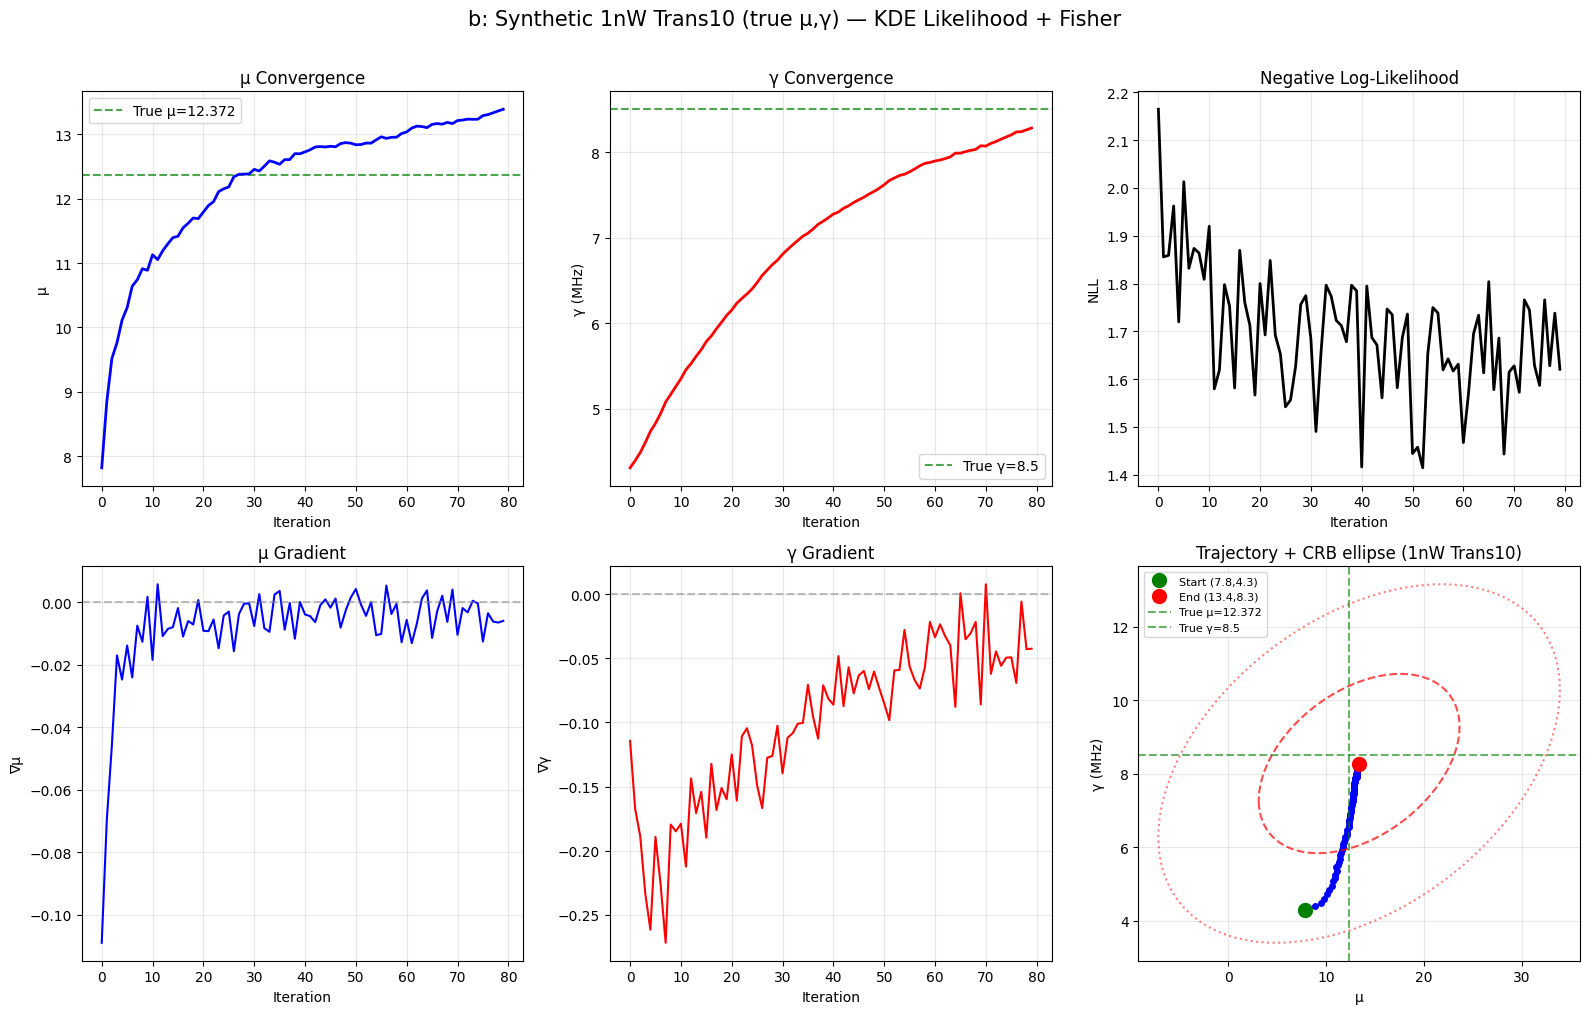

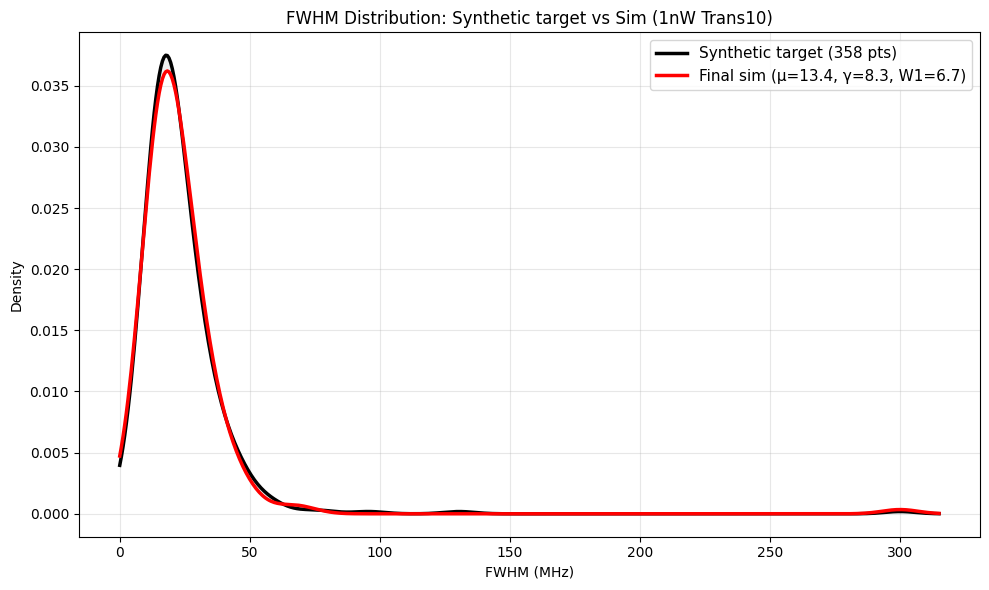

Target FWHM (synthetic): 23.4 ± 19.6 MHz
Final sim: 23.6 ± 24.0 MHz
Recovered: μ = 13.39 (true 12.372, Δ=+1.02, 0.10σ) | γ = 8.28 MHz (true γ 8.5, Δγ=-0.22, 0.09σ; σ_γ=2.44)


In [8]:
from scipy.stats import gaussian_kde
from src.losses import wasserstein_loss

steps = [h['step'] for h in history]
mu_hist = [h['mu'] for h in history]
gamma_hist = [h['gamma'] for h in history]

# fresh forward pass at the recovered parameters
rng_f = np.random.default_rng(999)
final_fwhms = []
for _ in range(500):
    u, b, n = draw_fixed_noise(mu_hist[-1], SIGMA_PROP, LAMBDA_, rng_f)
    photons = build_photons(torch.tensor(gamma_hist[-1], dtype=torch.float32), u, b)
    theta = fit_profile(photons, n_iters=80, model='lorentzian', uniform_bg=False)
    if theta is not None:
        final_fwhms.append(fwhm_from_theta(theta, model='lorentzian').item())
    else:
        final_fwhms.append(2.0 * gamma_hist[-1])
final_t = torch.tensor(final_fwhms, dtype=torch.float32)
w1_final = wasserstein_loss(final_t, target_f).item()

def cov_to_ellipse(cov2, level=1.0):
    eigvals, eigvecs = np.linalg.eigh(cov2)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    theta = np.linspace(0, 2 * np.pi, 100)
    xy = np.vstack([level * np.sqrt(eigvals[0]) * np.cos(theta),
                    level * np.sqrt(eigvals[1]) * np.sin(theta)])
    return eigvecs @ xy

Jinv_np = Jinv.numpy()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

ax = axes[0, 0]
ax.axhline(MU_TRUE, color='g', ls='--', linewidth=1.5, alpha=0.7, label=f'True μ={MU_TRUE}')
ax.plot(steps, mu_hist, 'b-', linewidth=2)
ax.set_xlabel('Iteration'); ax.set_ylabel('μ')
ax.set_title('μ Convergence'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.axhline(GAMMA_TRUE, color='g', ls='--', linewidth=1.5, alpha=0.7, label=f'True γ={GAMMA_TRUE}')
ax.plot(steps, gamma_hist, 'r-', linewidth=2)
ax.set_xlabel('Iteration'); ax.set_ylabel('γ (MHz)')
ax.set_title('γ Convergence'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[0, 2]
ax.plot(steps, [h['nll'] for h in history], 'k-', linewidth=2)
ax.set_xlabel('Iteration'); ax.set_ylabel('NLL')
ax.set_title('Negative Log-Likelihood'); ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.plot(steps, [h['grad_mu'] for h in history], 'b-', linewidth=1.5)
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Iteration'); ax.set_ylabel('∇μ')
ax.set_title('μ Gradient'); ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.plot(steps, [h['grad_gamma'] for h in history], 'r-', linewidth=1.5)
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Iteration'); ax.set_ylabel('∇γ')
ax.set_title('γ Gradient'); ax.grid(alpha=0.3)

ax = axes[1, 2]
ax.plot(mu_hist, gamma_hist, 'b.-', linewidth=1.5, markersize=8)
ax.plot(mu_hist[0], gamma_hist[0], 'go', markersize=10, label=f'Start ({mu_hist[0]:.1f},{gamma_hist[0]:.1f})')
ax.plot(mu_hist[-1], gamma_hist[-1], 'ro', markersize=10, label=f'End ({mu_hist[-1]:.1f},{gamma_hist[-1]:.1f})')
xy1 = cov_to_ellipse(Jinv_np, level=1.0)
xy2 = cov_to_ellipse(Jinv_np, level=2.0)
ax.plot(xy1[0] + mu_hist[-1], xy1[1] + gamma_hist[-1], 'r--', alpha=0.7, linewidth=1.5)
ax.plot(xy2[0] + mu_hist[-1], xy2[1] + gamma_hist[-1], 'r:', alpha=0.5, linewidth=1.5)
ax.axvline(MU_TRUE, color='g', ls='--', alpha=0.6, label=f'True μ={MU_TRUE}')
ax.axhline(GAMMA_TRUE, color='g', ls='--', alpha=0.6, label=f'True γ={GAMMA_TRUE}')
ax.set_xlabel('μ'); ax.set_ylabel('γ (MHz)')
ax.set_title('Trajectory + CRB ellipse (1nW Trans10)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle('b: Synthetic 1nW Trans10 (true μ,γ) — KDE Likelihood + Fisher', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('fig_16_1nWTrans10.png', dpi=150, bbox_inches='tight')
plt.show()

x_grid = np.linspace(0, max(target_f.max(), final_t.max()).item() * 1.05, 500)
kde_target = gaussian_kde(target_f.numpy())
kde_final = gaussian_kde(final_t.numpy())
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_grid, kde_target(x_grid), 'k-', linewidth=2.5, label=f'Synthetic target ({len(target_f)} pts)')
ax.plot(x_grid, kde_final(x_grid), 'r-', linewidth=2.5, label=f'Final sim (μ={mu_hist[-1]:.1f}, γ={gamma_hist[-1]:.1f}, W1={w1_final:.1f})')
ax.fill_between(x_grid, kde_final(x_grid), kde_target(x_grid), alpha=0.12, color='gray')
ax.set_xlabel('FWHM (MHz)'); ax.set_ylabel('Density')
ax.set_title('FWHM Distribution: Synthetic target vs Sim (1nW Trans10)')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_16_1nWTrans10_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Target FWHM (synthetic): {target_f.mean():.1f} ± {target_f.std():.1f} MHz')
print(f'Final sim: {final_t.mean():.1f} ± {final_t.std():.1f} MHz')
print(f'Recovered: μ = {mu_hist[-1]:.2f} (true {MU_TRUE}, Δ={mu_hist[-1]-MU_TRUE:+.2f}, {abs(mu_hist[-1]-MU_TRUE)/std_mu:.2f}σ) | '
      f'γ = {gamma_hist[-1]:.2f} MHz (true γ {GAMMA_TRUE}, Δγ={gamma_hist[-1]-GAMMA_TRUE:+.2f}, '
      f'{abs(gamma_hist[-1]-GAMMA_TRUE)/std_gamma:.2f}σ; σ_γ={std_gamma:.2f})')